# Full-FE Egitimi: In-silico Skorlar + Gelismis FE

In-silico meta-predictor skorlari korunur + yeni FE feature'lari eklenir.
Sonuclar onceki modlarla (no_fe, with_fe, clean, clean_fe) karsilastirilir.

In [1]:
import sys, os, warnings, time
import pandas as pd
import numpy as np
import joblib
import torch
import copy

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) != 'notebooks':
    PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from config import *
from src.features import prepare_data
from src.models import MODEL_BUILDERS
from src.stacking import STACKING_BUILDERS
from src.metrics import optimize_threshold, compute_all_metrics
from src.utils import get_train_test_data
from sklearn.metrics import f1_score as _f1_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Tum builder'lari birlestir
ALL_BUILDERS = {**MODEL_BUILDERS, **STACKING_BUILDERS}

print(f'Proje koku: {PROJECT_ROOT}')
print(f'Model tipleri: {list(ALL_BUILDERS.keys())}')
print(f'Optuna trial: Agac={TRIALS_TREE}, NN={TRIALS_NN}')

c:\Users\ahmet.ceyhan23\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Proje koku: c:\Users\ahmet.ceyhan23\Desktop\teknofest_model
Model tipleri: ['lightgbm', 'xgboost', 'nn', 'dnn', 'stacking_lr', 'stacking_lgbm']
Optuna trial: Agac=100, NN=50


In [2]:
# Veri yukle ve full_fe hazirla
df_raw = pd.read_csv(DATA_PATH)
print(f'Veri boyutu: {df_raw.shape}')
print(f'Sinif dagilimi:\n{df_raw["target"].value_counts()}')

df_full_fe = prepare_data(df_raw.copy(), 'full_fe')
print(f'\nFull-FE boyutu: {df_full_fe.shape}')

Veri boyutu: (4287, 119)
Sinif dagilimi:
target
0    2920
1    1367
Name: count, dtype: int64
  Conservation PCA: 4 skor -> 2 PC (varyans: 97.69%)
  DNA_11mer_Ref/DNA_11mer_Alt: 16 k-mer + 16 delta
  Prot_11mer_Ref/Prot_11mer_Alt: 431 k-mer + 431 delta
  mutation_type: 12 one-hot feature
  aa_change: 150 one-hot feature
  60 gereksiz sutun kaldirildi (in-silico skorlar KORUNDU)
  r>0.99 kopya filtreleme: 22 sutun dusuruldu
  Sifir varyans filtreleme: 13 sutun dusuruldu
[Full-FE] Veri boyutu: 4287 x 1531

Full-FE boyutu: (4287, 1531)


In [3]:
# Konfigurasyon listesi: full_fe x (4 model + 2 stacking)
CONFIGS = []
ALL_MODEL_TYPES = MODEL_TYPES + STACKING_TYPES

for model_type in ALL_MODEL_TYPES:
    # Multi-panel
    CONFIGS.append({
        'config_id': f'{model_type}_full_fe_multi_panel',
        'model_type': model_type,
        'fe_state': 'full_fe',
        'mode': 'multi_panel',
        'panel': None,
    })
    # Single-panel
    for panel in PANELS_SINGLE:
        CONFIGS.append({
            'config_id': f'{model_type}_full_fe_single_{panel}',
            'model_type': model_type,
            'fe_state': 'full_fe',
            'mode': 'single_panel',
            'panel': panel,
        })

print(f'Toplam konfigurasyon: {len(CONFIGS)}')
for c in CONFIGS:
    print(f'  {c["config_id"]}')

Toplam konfigurasyon: 24
  lightgbm_full_fe_multi_panel
  lightgbm_full_fe_single_General
  lightgbm_full_fe_single_Hereditary_Cancer
  lightgbm_full_fe_single_PAH
  xgboost_full_fe_multi_panel
  xgboost_full_fe_single_General
  xgboost_full_fe_single_Hereditary_Cancer
  xgboost_full_fe_single_PAH
  nn_full_fe_multi_panel
  nn_full_fe_single_General
  nn_full_fe_single_Hereditary_Cancer
  nn_full_fe_single_PAH
  dnn_full_fe_multi_panel
  dnn_full_fe_single_General
  dnn_full_fe_single_Hereditary_Cancer
  dnn_full_fe_single_PAH
  stacking_lr_full_fe_multi_panel
  stacking_lr_full_fe_single_General
  stacking_lr_full_fe_single_Hereditary_Cancer
  stacking_lr_full_fe_single_PAH
  stacking_lgbm_full_fe_multi_panel
  stacking_lgbm_full_fe_single_General
  stacking_lgbm_full_fe_single_Hereditary_Cancer
  stacking_lgbm_full_fe_single_PAH


In [4]:
def run_single_config(config, df_prepared, use_focal=False):
    config_id = config['config_id']
    model_type = config['model_type']
    mode = config['mode']
    panel = config.get('panel', None)

    X_train, X_test, y_train, y_test, cat_features = get_train_test_data(
        df_prepared, mode, panel
    )
    print(f'  Veri: {X_train.shape[0]} train, {X_test.shape[0]} test, {X_train.shape[1]} feature')

    builder = ALL_BUILDERS[model_type]
    start_time = time.time()
    model, study, best_thr, y_pred_proba = builder(
        X_train, y_train, X_test, y_test, cat_features, use_focal=use_focal
    )
    elapsed = time.time() - start_time

    y_pred = (y_pred_proba >= best_thr).astype(int)
    metrics = compute_all_metrics(y_test, y_pred, y_pred_proba)

    y_pred_default = (y_pred_proba >= 0.5).astype(int)
    f1_default = _f1_score(y_test, y_pred_default, zero_division=0)

    return {
        'config_id': config_id,
        'model_type': model_type,
        'fe_state': 'full_fe',
        'mode': mode,
        'panel': panel if panel else 'All',
        'best_threshold': best_thr,
        'f1_default': f1_default,
        'best_cv_f1': study.best_value if study else metrics['f1'],
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'n_features': X_train.shape[1],
        **metrics,
        'time_seconds': elapsed,
        '_model': model,
        '_study': study,
        '_y_test': y_test.values,
        '_y_pred_proba': y_pred_proba,
        '_y_pred': y_pred,
        '_feature_names': list(X_train.columns) if hasattr(X_train, 'columns') else None,
    }

In [5]:
# === EGITIM DONGUSU ===
RESULTS = {}
total = len(CONFIGS)

for i, config in enumerate(CONFIGS, 1):
    config_id = config['config_id']
    print(f'\n[{i}/{total}] {config_id}')
    print('-' * 50)

    try:
        result = run_single_config(config, df_full_fe, use_focal=True)
        RESULTS[config_id] = result
        print(f'  F1={result["f1"]:.4f} | AUC-ROC={result["auc_roc"]:.4f} | '
              f'Threshold={result["best_threshold"]:.2f} | {result["time_seconds"]:.1f}s')
    except Exception as e:
        print(f'  HATA: {e}')
        import traceback
        traceback.print_exc()

print(f'\n{"="*60}')
print(f'Tamamlanan: {len(RESULTS)}/{total}')


[1/24] lightgbm_full_fe_multi_panel
--------------------------------------------------
  Veri: 3429 train, 858 test, 1533 feature


Best trial: 96. Best value: 0.694021: 100%|██████████| 100/100 [09:47<00:00,  5.88s/it]


  F1=0.6967 | AUC-ROC=0.8721 | Threshold=0.44 | 589.4s

[2/24] lightgbm_full_fe_single_General
--------------------------------------------------
  Veri: 2524 train, 632 test, 1529 feature


Best trial: 61. Best value: 0.675497: 100%|██████████| 100/100 [12:20<00:00,  7.41s/it]


  F1=0.6637 | AUC-ROC=0.8381 | Threshold=0.30 | 743.4s

[3/24] lightgbm_full_fe_single_Hereditary_Cancer
--------------------------------------------------
  Veri: 572 train, 143 test, 1529 feature


...

  F1=0.5870 | AUC-ROC=0.7140 | Threshold=0.50 | 1279.0s

[15/24] dnn_full_fe_single_Hereditary_Cancer
--------------------------------------------------
  Veri: 572 train, 143 test, 1529 feature


Best trial: 46. Best value: 0.661632: 100%|██████████| 50/50 [04:02<00:00,  4.85s/it]


  F1=0.6977 | AUC-ROC=0.8642 | Threshold=0.51 | 248.2s

[16/24] dnn_full_fe_single_PAH
--------------------------------------------------
  Veri: 259 train, 65 test, 1529 feature


Best trial: 34. Best value: 0.535625: 100%|██████████| 50/50 [03:01<00:00,  3.63s/it]


  F1=0.5000 | AUC-ROC=0.4708 | Threshold=0.50 | 183.4s

[17/24] stacking_lr_full_fe_multi_panel
--------------------------------------------------
  Veri: 3429 train, 858 test, 1533 feature
  Stacking (LR meta-learner) egitiliyor...
  Stacking F1: 0.6918 (threshold: 0.53)
  F1=0.6918 | AUC-ROC=0.8567 | Threshold=0.53 | 126.5s

[18/24] stacking_lr_full_fe_single_General
--------------------------------------------------
  Veri: 2524 train, 632 test, 1529 feature
  Stacking (LR meta-learner) egitiliyor...
  Stacking F1: 0.6411 (threshold: 0.42)
  F1=0.6411 | AUC-ROC=0.8151 | Threshold=0.42 | 75.9s

[19/24] stacking_lr_full_fe_single_Hereditary_Cancer
--------------------------------------------------
  Veri: 572 train, 143 test, 1529 feature
  Stacking (LR meta-learner) egitiliyor...
  Stacking F1: 0.7952 (threshold: 0.59)
  F1=0.7952 | AUC-ROC=0.9255 | Threshold=0.59 | 31.5s

[20/24] stacking_lr_full_fe_single_PAH
--------------------------------------------------
  Veri: 259 train, 65 

In [6]:
# Sonuclari kaydet
csv_cols = ['config_id', 'model_type', 'fe_state', 'mode', 'panel',
            'best_threshold', 'f1_default', 'best_cv_f1',
            'n_train', 'n_test', 'n_features',
            'f1', 'auc_roc', 'auc_pr', 'mcc', 'precision', 'recall',
            'specificity', 'balanced_accuracy', 'cohens_kappa', 'time_seconds']

results_list = [{k: v for k, v in r.items() if not k.startswith('_')}
                for r in RESULTS.values()]
results_df = pd.DataFrame(results_list)[csv_cols]

os.makedirs(RESULTS_V2_DIR, exist_ok=True)
results_df.to_csv(os.path.join(RESULTS_V2_DIR, 'full_fe_results.csv'), index=False)
print(f'Sonuclar kaydedildi: {RESULTS_V2_DIR}/full_fe_results.csv')

print(f'\nFULL-FE SONUCLARI:')
print(results_df[['config_id', 'f1', 'auc_roc', 'mcc', 'precision', 'recall']].to_string(index=False))

Sonuclar kaydedildi: c:\Users\ahmet.ceyhan23\Desktop\teknofest_model\results\v2_clean/full_fe_results.csv

FULL-FE SONUCLARI:
                                     config_id       f1  auc_roc      mcc  precision   recall
                  lightgbm_full_fe_multi_panel 0.696667 0.872113 0.540240   0.641104 0.762774
               lightgbm_full_fe_single_General 0.663697 0.838127 0.493496   0.586614 0.764103
     lightgbm_full_fe_single_Hereditary_Cancer 0.759494 0.918639 0.667829   0.750000 0.769231
                   lightgbm_full_fe_single_PAH 0.561404 0.652597 0.289156   0.444444 0.761905
                   xgboost_full_fe_multi_panel 0.687879 0.854558 0.521259   0.588083 0.828467
                xgboost_full_fe_single_General 0.639485 0.828199 0.452580   0.549815 0.764103
      xgboost_full_fe_single_Hereditary_Cancer 0.775000 0.912599 0.688112   0.756098 0.794872
                    xgboost_full_fe_single_PAH 0.545455 0.649351 0.314363   0.521739 0.571429
                        nn_f

In [7]:
# Onceki sonuclarla karsilastirma
prev_path = os.path.join(RESULTS_V2_DIR, 'model_comparison_results.csv')
stack_path = os.path.join(RESULTS_V2_DIR, 'stacking_results.csv')

if os.path.exists(prev_path):
    prev_df = pd.read_csv(prev_path)
    print('=' * 70)
    print('KARSILASTIRMA: Onceki Modlar vs Full-FE')
    print('=' * 70)

    # FE modu bazinda ortalama F1
    print('\nFE Modu bazinda ortalama F1:')
    all_results = pd.concat([prev_df, results_df], ignore_index=True)
    fe_avg = all_results.groupby('fe_state')['f1'].agg(['mean', 'max', 'min']).sort_values('mean', ascending=False)
    print(fe_avg.to_string())

    # Model tipi x FE modu
    print('\nModel tipi x FE modu (ortalama F1):')
    pivot = all_results.pivot_table(values='f1', index='model_type', columns='fe_state', aggfunc='mean')
    print(pivot.to_string())

    # Panel bazinda en iyi
    print('\nPanel bazinda en iyi F1 (full_fe vs diger):')
    for panel in ['All'] + PANELS_SINGLE:
        p_prev = prev_df[prev_df['panel'] == panel]
        p_full = results_df[results_df['panel'] == panel]
        best_prev = p_prev['f1'].max() if len(p_prev) > 0 else 0
        best_prev_mode = p_prev.loc[p_prev['f1'].idxmax(), 'fe_state'] if len(p_prev) > 0 else '-'
        best_full = p_full['f1'].max() if len(p_full) > 0 else 0
        delta = best_full - best_prev
        print(f'  {panel:25s}: onceki={best_prev:.4f} ({best_prev_mode:10s}) | full_fe={best_full:.4f} | delta={delta:+.4f}')

    # Birlesik CSV kaydet
    all_results.to_csv(os.path.join(RESULTS_V2_DIR, 'all_results_combined.csv'), index=False)
    print(f'\nBirlesik sonuclar: {RESULTS_V2_DIR}/all_results_combined.csv')
else:
    print('Onceki sonuclar bulunamadi.')

KARSILASTIRMA: Onceki Modlar vs Full-FE

FE Modu bazinda ortalama F1:
              mean       max       min
fe_state                              
with_fe   0.656150  0.814815  0.553191
no_fe     0.643307  0.794872  0.500000
full_fe   0.642491  0.795181  0.500000
clean_fe  0.571594  0.652632  0.493827
clean     0.556843  0.622222  0.488372

Model tipi x FE modu (ortalama F1):
fe_state          clean  clean_fe   full_fe     no_fe   with_fe
model_type                                                     
dnn            0.534488  0.559837  0.596158  0.618155  0.637315
lightgbm       0.584091  0.603887  0.670315  0.659696  0.665220
nn             0.541476  0.552113  0.614852  0.630970  0.638018
stacking_lgbm       NaN       NaN  0.643268       NaN       NaN
stacking_lr         NaN       NaN  0.668397       NaN       NaN
xgboost        0.567316  0.570540  0.661955  0.664409  0.684049

Panel bazinda en iyi F1 (full_fe vs diger):
  All                      : onceki=0.7097 (no_fe     ) | full_

In [8]:
# En iyi modelleri kaydet
os.makedirs(MODELS_V2_DIR, exist_ok=True)

def _safe_save_model(model, path):
    if hasattr(model, 'state_dict'):
        torch.save(model.state_dict(), path + '.pt')
        return path + '.pt'
    elif hasattr(model, 'save_model'):
        model.save_model(path + '.json')
        return path + '.json'
    else:
        m = copy.deepcopy(model)
        if hasattr(m, '_objective') and callable(m._objective):
            m._objective = None
        if hasattr(m, 'objective') and callable(m.objective):
            m.objective = None
        joblib.dump(m, path + '.joblib')
        return path + '.joblib'

for panel in ['All'] + PANELS_SINGLE:
    panel_results = {k: v for k, v in RESULTS.items() if v['panel'] == panel}
    if not panel_results:
        continue
    best_key = max(panel_results, key=lambda k: panel_results[k]['f1'])
    best = panel_results[best_key]
    model_name = f'best_{panel}_{best["model_type"]}_full_fe'
    save_path = os.path.join(MODELS_V2_DIR, model_name)
    try:
        saved = _safe_save_model(best['_model'], save_path)
        print(f'Kaydedildi: {os.path.basename(saved)} (F1={best["f1"]:.4f})')
    except Exception as e:
        print(f'UYARI: {model_name} kaydedilemedi: {e}')

# Optuna study kaydet
os.makedirs(STUDIES_DIR, exist_ok=True)
for config_id, result in RESULTS.items():
    study = result.get('_study')
    if study is not None:
        try:
            joblib.dump(study, os.path.join(STUDIES_DIR, f'optuna_study_{config_id}.joblib'))
        except Exception as e:
            print(f'UYARI: Study {config_id} kaydedilemedi: {e}')

print('\nTum modeller kaydedildi.')

Kaydedildi: best_All_lightgbm_full_fe.joblib (F1=0.6967)
Kaydedildi: best_General_lightgbm_full_fe.joblib (F1=0.6637)
Kaydedildi: best_Hereditary_Cancer_stacking_lr_full_fe.joblib (F1=0.7952)
Kaydedildi: best_PAH_nn_full_fe.pt (F1=0.5882)

Tum modeller kaydedildi.


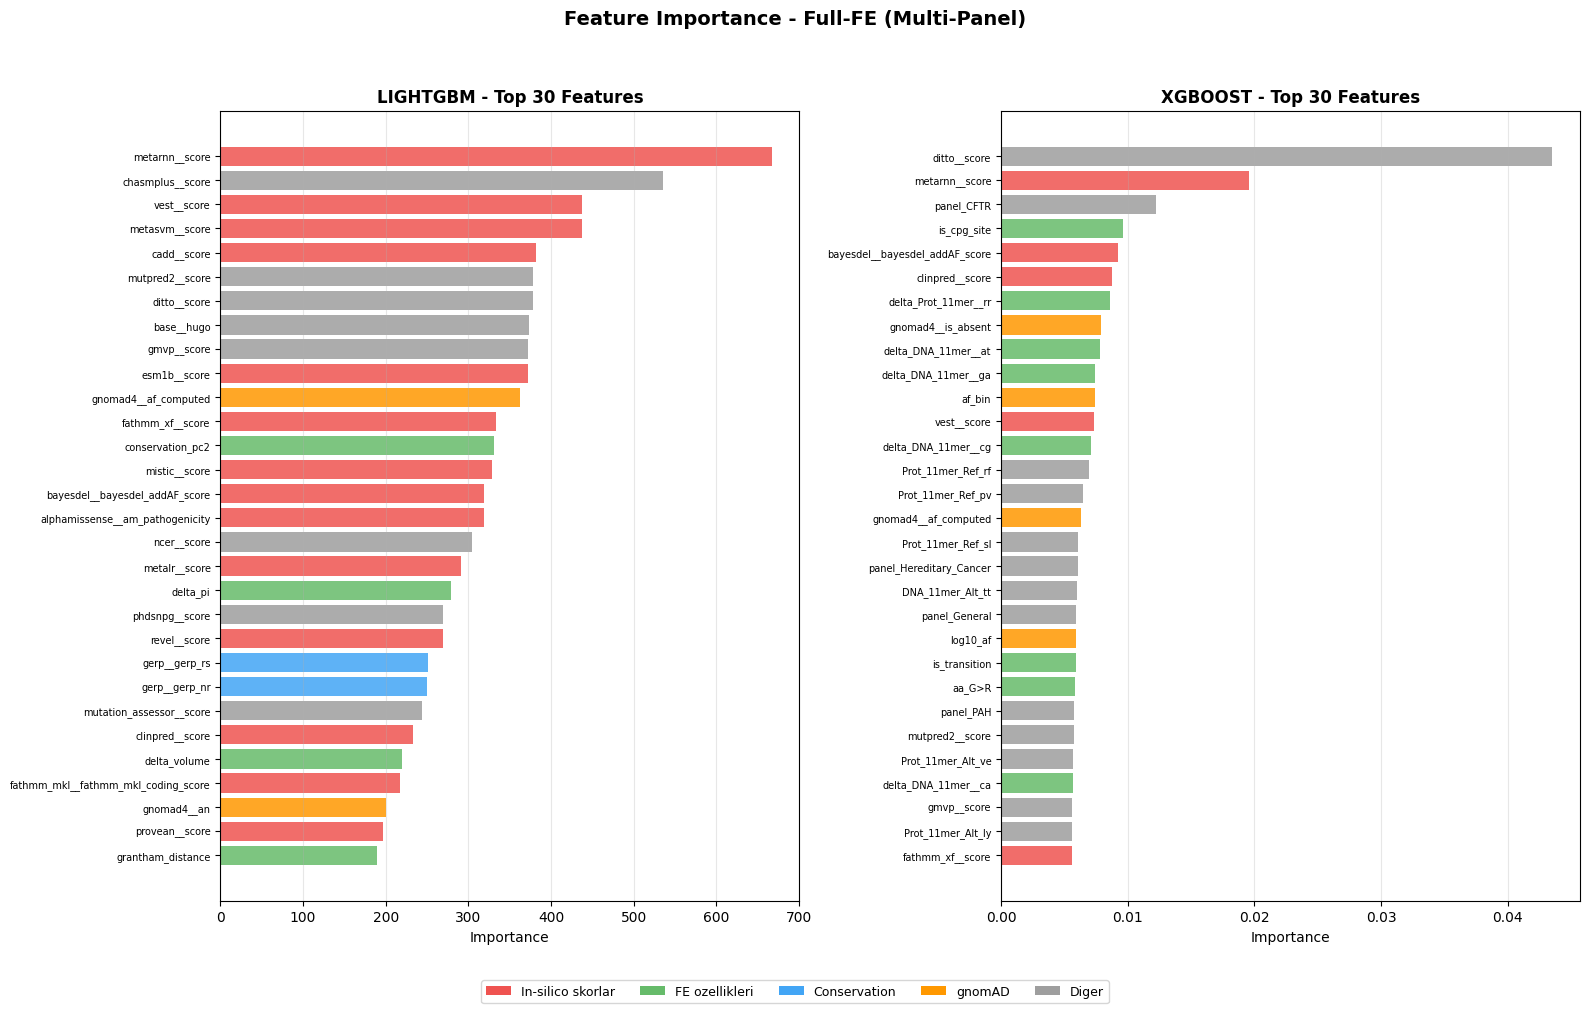

Feature importance grafigi kaydedildi.


In [9]:
# Feature Importance Analizi (LightGBM & XGBoost)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Feature Importance - Full-FE (Multi-Panel)', fontsize=14, fontweight='bold')

for idx, mt in enumerate(['lightgbm', 'xgboost']):
    ax = axes[idx]
    config_key = f'{mt}_full_fe_multi_panel'
    if config_key not in RESULTS:
        ax.set_title(f'{mt} - sonuc bulunamadi')
        continue

    result = RESULTS[config_key]
    model = result['_model']
    feature_names = result['_feature_names']

    if mt == 'lightgbm':
        importances = model.feature_importances_
    else:  # xgboost
        importances = model.feature_importances_

    # Top 30 feature
    top_n = 30
    sorted_idx = np.argsort(importances)[-top_n:]
    top_features = [feature_names[i] for i in sorted_idx]
    top_importances = importances[sorted_idx]

    colors = []
    for f in top_features:
        if any(x in f.lower() for x in ['revel', 'cadd', 'clinpred', 'alphamissense', 'metasvm',
                                          'metalr', 'metarnn', 'sift', 'vest', 'bayesdel',
                                          'fathmm', 'esm1b', 'mistic', 'provean', 'mutationtaster']):
            colors.append('#EF5350')  # In-silico: kirmizi
        elif any(x in f.lower() for x in ['grantham', 'blosum', 'delta_', 'conservation',
                                            'gerp_x', 'is_cpg', 'gc_content', 'is_transition',
                                            'mut_', 'aa_']):
            colors.append('#66BB6A')  # FE: yesil
        elif any(x in f.lower() for x in ['gerp', 'phylop', 'phastcons']):
            colors.append('#42A5F5')  # Conservation: mavi
        elif any(x in f.lower() for x in ['gnomad', 'log10_af', 'af_bin', 'homozygote']):
            colors.append('#FF9800')  # gnomAD: turuncu
        else:
            colors.append('#9E9E9E')  # Diger: gri

    ax.barh(range(top_n), top_importances, color=colors, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features, fontsize=7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{mt.upper()} - Top {top_n} Features', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF5350', label='In-silico skorlar'),
    Patch(facecolor='#66BB6A', label='FE ozellikleri'),
    Patch(facecolor='#42A5F5', label='Conservation'),
    Patch(facecolor='#FF9800', label='gnomAD'),
    Patch(facecolor='#9E9E9E', label='Diger'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(RESULTS_V2_DIR, 'feature_importance_full_fe.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance grafigi kaydedildi.')

In [13]:
# === HIZLI TEST: LightGBM & XGBoost (n_estimators=100, Optuna yok) ===
import sys, os, warnings, time
import pandas as pd
import numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) != 'notebooks':
    PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from config import *
from src.features import prepare_data
from src.utils import get_train_test_data, prepare_for_xgb
from src.metrics import optimize_threshold, compute_all_metrics
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

# Veri hazirla
df_raw = pd.read_csv(DATA_PATH)
df_full_fe = prepare_data(df_raw.copy(), 'full_fe')

X_train, X_test, y_train, y_test, cat_features = get_train_test_data(df_full_fe, 'multi_panel', None)
print(f'Veri: {X_train.shape[0]} train, {X_test.shape[0]} test, {X_train.shape[1]} feature')

# --- LightGBM ---
t0 = time.time()
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train, categorical_feature=cat_features)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
thr_lgbm, _ = optimize_threshold(y_test, y_prob_lgbm)
y_pred_lgbm = (y_prob_lgbm >= thr_lgbm).astype(int)
m_lgbm = compute_all_metrics(y_test, y_pred_lgbm, y_prob_lgbm)
print(f'\nLightGBM ({time.time()-t0:.1f}s): F1={m_lgbm["f1"]:.4f} AUC-ROC={m_lgbm["auc_roc"]:.4f} '
      f'MCC={m_lgbm["mcc"]:.4f} Prec={m_lgbm["precision"]:.4f} Recall={m_lgbm["recall"]:.4f} Thr={thr_lgbm:.2f}')

# --- XGBoost ---
t0 = time.time()
X_train_xgb, X_test_xgb, _ = prepare_for_xgb(X_train, X_test, cat_features)
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train_xgb, y_train)
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]
thr_xgb, _ = optimize_threshold(y_test, y_prob_xgb)
y_pred_xgb = (y_prob_xgb >= thr_xgb).astype(int)
m_xgb = compute_all_metrics(y_test, y_pred_xgb, y_prob_xgb)
print(f'XGBoost  ({time.time()-t0:.1f}s): F1={m_xgb["f1"]:.4f} AUC-ROC={m_xgb["auc_roc"]:.4f} '
      f'MCC={m_xgb["mcc"]:.4f} Prec={m_xgb["precision"]:.4f} Recall={m_xgb["recall"]:.4f} Thr={thr_xgb:.2f}')


  Conservation PCA: 4 skor -> 2 PC (varyans: 97.69%)
  DNA_11mer_Ref/DNA_11mer_Alt: 16 k-mer + 16 delta
  Prot_11mer_Ref/Prot_11mer_Alt: 431 k-mer + 431 delta
  mutation_type: 12 one-hot feature
  aa_change: 150 one-hot feature
  60 gereksiz sutun kaldirildi (in-silico skorlar KORUNDU)
  r>0.99 kopya filtreleme: 22 sutun dusuruldu
  Sifir varyans filtreleme: 13 sutun dusuruldu
[Full-FE] Veri boyutu: 4287 x 1531
Veri: 3429 train, 858 test, 1533 feature

LightGBM (0.8s): F1=0.6914 AUC-ROC=0.8635 MCC=0.5293 Prec=0.6203 Recall=0.7810 Thr=0.35
XGBoost  (2.3s): F1=0.6751 AUC-ROC=0.8519 MCC=0.5021 Prec=0.5966 Recall=0.7774 Thr=0.30


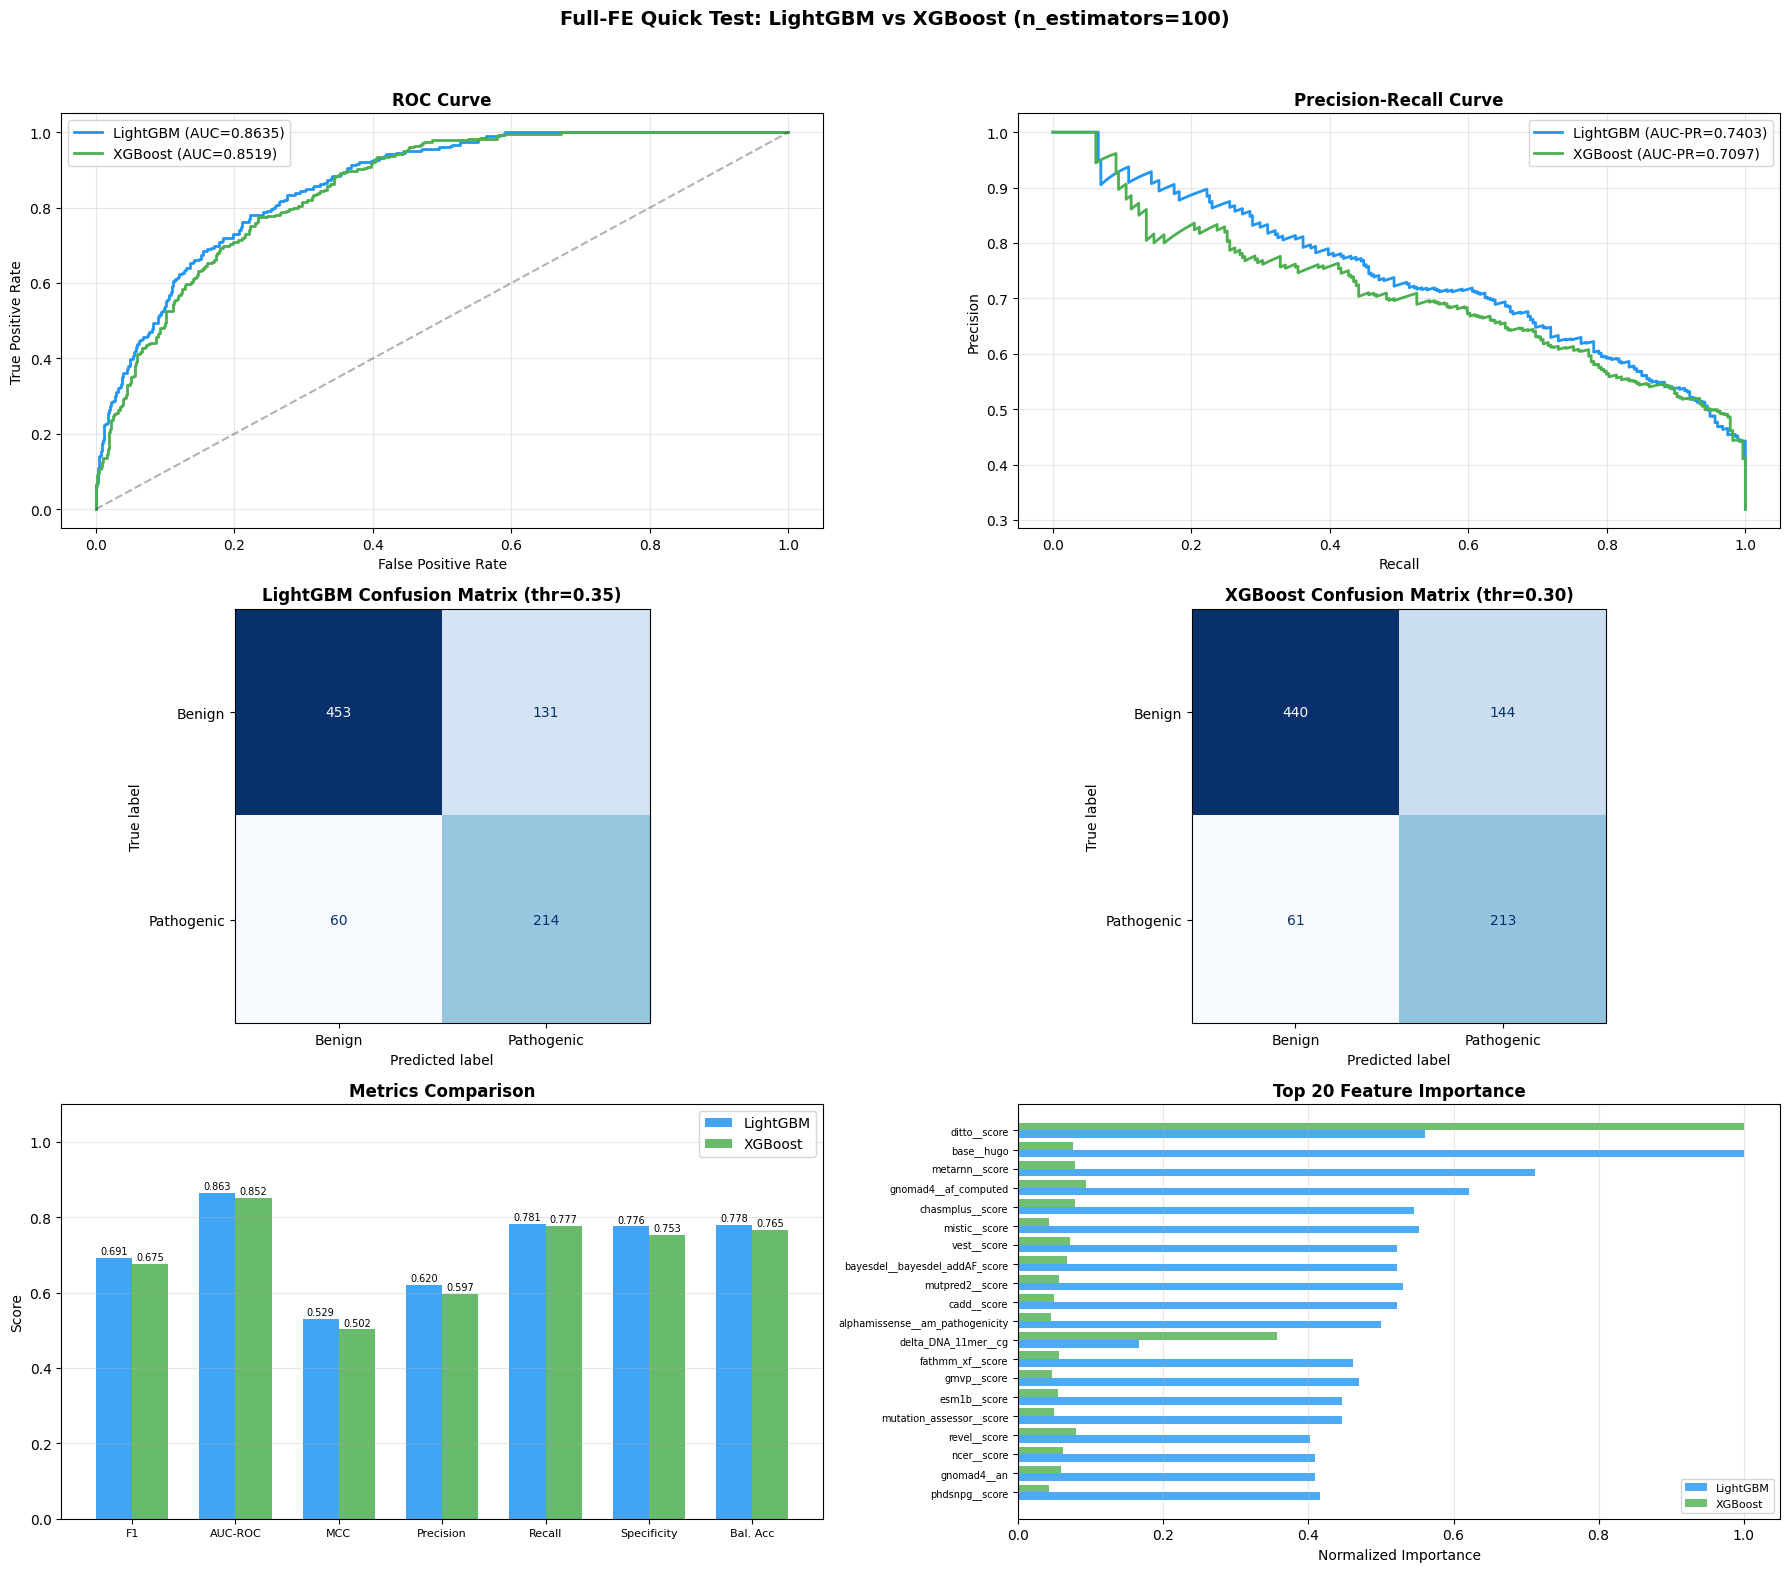

Grafikler kaydedildi: results/v2_clean/quick_test_full_fe.png


In [14]:
# === GRAFIKLER: Hizli Test Sonuclari ===
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Full-FE Quick Test: LightGBM vs XGBoost (n_estimators=100)', fontsize=14, fontweight='bold')

models_info = [
    ('LightGBM', y_prob_lgbm, y_pred_lgbm, m_lgbm, thr_lgbm, lgbm, X_train.columns.tolist(), '#2196F3'),
    ('XGBoost', y_prob_xgb, y_pred_xgb, m_xgb, thr_xgb, xgb, X_train.columns.tolist(), '#4CAF50'),
]

# --- 1. ROC Curve ---
ax = fig.add_subplot(3, 2, 1)
for name, yp, _, m, _, _, _, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={m["auc_roc"]:.4f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# --- 2. Precision-Recall Curve ---
ax = fig.add_subplot(3, 2, 2)
for name, yp, _, m, _, _, _, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, yp)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AUC-PR={m["auc_pr"]:.4f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# --- 3-4. Confusion Matrix ---
for i, (name, _, yp, m, thr, _, _, color) in enumerate(models_info):
    ax = fig.add_subplot(3, 2, 3 + i)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Pathogenic']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} Confusion Matrix (thr={thr:.2f})', fontweight='bold')

# --- 5. Metrik Karsilastirma ---
ax = fig.add_subplot(3, 2, 5)
metrics_keys = ['f1', 'auc_roc', 'mcc', 'precision', 'recall', 'specificity', 'balanced_accuracy']
metric_labels = ['F1', 'AUC-ROC', 'MCC', 'Precision', 'Recall', 'Specificity', 'Bal. Acc']
x = np.arange(len(metrics_keys))
w = 0.35
vals_lgbm = [m_lgbm[k] for k in metrics_keys]
vals_xgb = [m_xgb[k] for k in metrics_keys]
ax.bar(x - w/2, vals_lgbm, w, label='LightGBM', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, vals_xgb, w, label='XGBoost', color='#4CAF50', alpha=0.85)
for j, (v1, v2) in enumerate(zip(vals_lgbm, vals_xgb)):
    ax.text(j - w/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=7)
    ax.text(j + w/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Metrics Comparison', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# --- 6. Feature Importance (LightGBM + XGBoost overlay top 20) ---
ax = fig.add_subplot(3, 2, 6)
feat_names = X_train.columns.tolist()
imp_lgbm = lgbm.feature_importances_
imp_xgb = xgb.feature_importances_

# Normalize
imp_lgbm_n = imp_lgbm / imp_lgbm.max()
imp_xgb_n = imp_xgb / imp_xgb.max()

# Top 20 by combined rank
combined = imp_lgbm_n + imp_xgb_n
top_idx = np.argsort(combined)[-20:]
top_feat = [feat_names[i] for i in top_idx]
top_lgbm = imp_lgbm_n[top_idx]
top_xgb = imp_xgb_n[top_idx]

y_pos = np.arange(len(top_feat))
ax.barh(y_pos - 0.2, top_lgbm, 0.4, label='LightGBM', color='#2196F3', alpha=0.8)
ax.barh(y_pos + 0.2, top_xgb, 0.4, label='XGBoost', color='#4CAF50', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(top_feat, fontsize=7)
ax.set_xlabel('Normalized Importance')
ax.set_title('Top 20 Feature Importance', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(RESULTS_V2_DIR, 'quick_test_full_fe.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafikler kaydedildi: results/v2_clean/quick_test_full_fe.png')
